This takes the data of all countries and looks at short term and long term prediction accuracy. We then also compare different regions of Europe  
(there might be some errors popping up along running it those are harmless, also denmark reports for east, west and unified as separate)

In [ ]:
import os, re, numpy as np, pandas as pd, tensorflow as tf
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics     import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models  import Sequential
from tensorflow.keras.layers  import GRU, Dense, Dropout, InputLayer


In [4]:

# our evaluation standards set by the RQ
SEQ_LEN      = 24       
SHORT_H, LONG_H = 168, 8760
EPOCHS, BATCH  = 30, 64
tf.random.set_seed(42); np.random.seed(42)




# find data files {in case its in different roots try}
try:
    ROOT = os.path.dirname(os.path.abspath(__file__)) 
except NameError:
    ROOT = os.getcwd()   
    
    
ENERGY_CSV = os.path.join(os.path.dirname(os.getcwd()),
                          'clean_energy_data.csv')
OUT_CSV    = os.path.join(ROOT, "gru_horizon_metrics.csv")


print("reading", ENERGY_CSV)
df_all = pd.read_csv(ENERGY_CSV, parse_dates=["utc_timestamp"])
df_all.sort_values("utc_timestamp", inplace=True)







# sort and get countries
pat = re.compile(r"^(.+?)_(solar_generation_actual|wind_onshore_generation_actual)$")
codes = {}
for col in df_all.columns:
    m = pat.match(col)
    if m:
        codes.setdefault(m.group(1), set()).add(m.group(2))

CODES = sorted([c for c, s in codes.items() if {
    "solar_generation_actual",
    "wind_onshore_generation_actual"
}.issubset(s)])


if not CODES:
    raise RuntimeError("ERROR - no country has both solar & wind columns")

print("will evaluate:", ", ".join(CODES), "\n")





#making gru
def make_model(n_feat:int):
    m = Sequential([
        InputLayer((SEQ_LEN, n_feat)),
        GRU(128),
        Dropout(0.2),
        Dense(64, activation="relu"),
        Dense(1)
    ])
    m.compile("adam", "mse")
    return m







#main evaluation loop
results = []
for code in CODES:
    solar_col = f"{code}_solar_generation_actual"
    wind_col  = f"{code}_wind_onshore_generation_actual"


    #time part
    df = df_all[["utc_timestamp", solar_col, wind_col] +
                [c for c in df_all.columns if c not in ("utc_timestamp",
                                                        solar_col, wind_col)]
                ].copy()
    
    df["hour"]   = df.utc_timestamp.dt.hour
    df["dow"]    = df.utc_timestamp.dt.dayofweek
    df["month"]  = df.utc_timestamp.dt.month




    #lag features
    for t in (solar_col, wind_col):
        for l in (1, 24):
            df[f"{t}_lag{l}"] = df[t].shift(l)

    df = df.dropna().reset_index(drop=True)

    #predictors
    feature_cols = [c for c in df.columns
                    if c not in ("utc_timestamp", solar_col, wind_col)
                    and np.issubdtype(df[c].dtype, np.number)]


    #split transform sequence oh boy
    def prepare(target, horizon):
        train = df.iloc[:-horizon]
        test  = df.iloc[-(horizon+SEQ_LEN):]

        sx, sy = StandardScaler(), StandardScaler()
        Xtr = sx.fit_transform(train[feature_cols])
        ytr = sy.fit_transform(train[[target]])
        Xte = sx.transform(test[feature_cols])
        yte = sy.transform(test[[target]])

        def seq(X, y):
            xs, ys = [], []
            for i in range(SEQ_LEN, len(X)):
                xs.append(X[i-SEQ_LEN:i])
                ys.append(y[i, 0])
            return np.array(xs), np.array(ys)
        return *seq(Xtr, ytr), *seq(Xte, yte), sy

    for tgt, lbl in [(solar_col, "solar"), (wind_col, "wind")]:
        for h, tag in [(SHORT_H, "168h"), (LONG_H, "8760h")]:
            Xtr, ytr, Xte, yte, sy = prepare(tgt, h)
            model = make_model(Xtr.shape[2])
            model.fit(Xtr, ytr, epochs=EPOCHS, batch_size=BATCH, verbose=0)

            pred = model.predict(Xte, verbose=0).flatten()
            y_true = sy.inverse_transform(yte.reshape(-1,1))[:,0]
            y_pred = sy.inverse_transform(pred.reshape(-1,1))[:,0]

            mae  = mean_absolute_error(y_true, y_pred)
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            r2   = r2_score(y_true, y_pred)

            results.append(dict(Country=code, Target=lbl, Horizon=tag,
                                MAE=round(mae,2), RMSE=round(rmse,2), R2=round(r2,4)))
            print(f"{code:5s} {lbl:5s} {tag}  →  "
                  f"MAE={mae:8.1f}  RMSE={rmse:8.1f}  R²={r2:6.3f}")





#saving and finish
pd.DataFrame(results).to_csv(OUT_CSV, index=False)
print("results written to", OUT_CSV)


🔍  reading C:\Users\janek\OneDrive - PORG – gymnázium a základní škola, o. p. s\Dokumenty\Project-2-2\my_shit\clean_energy_data.csv
✅  will evaluate: BE, BG, CH, CZ, DK, DK_1, DK_2, EE, ES, FR, GR, LT, RO, SI 

BE    solar 168h  →  MAE=    41.2  RMSE=    94.4  R²= 0.805
BE    solar 8760h  →  MAE=    96.6  RMSE=   177.0  R²= 0.921
BE    wind  168h  →  MAE=    74.0  RMSE=   102.5  R²= 0.792
BE    wind  8760h  →  MAE=    86.7  RMSE=   124.7  R²= 0.877
BG    solar 168h  →  MAE=    24.7  RMSE=    46.3  R²= 0.860
BG    solar 8760h  →  MAE=    34.7  RMSE=    60.9  R²= 0.927
BG    wind  168h  →  MAE=    62.5  RMSE=    74.9  R²= 0.633
BG    wind  8760h  →  MAE=    47.4  RMSE=    64.7  R²= 0.742
CH    solar 168h  →  MAE=     3.4  RMSE=     4.8  R²= 0.904
CH    solar 8760h  →  MAE=    10.3  RMSE=    18.8  R²= 0.938
CH    wind  168h  →  MAE=     1.6  RMSE=     2.5  R²= 0.762
CH    wind  8760h  →  MAE=     4.3  RMSE=     5.5  R²= 0.620
CZ    solar 168h  →  MAE=    19.1  RMSE=    44.9  R²= 0.854
CZ 

now for some graphs and analytics

loading: C:\Users\janek\OneDrive - PORG – gymnázium a základní škola, o. p. s\Dokumenty\Project-2-2\my_shit\notebooks\gru_horizon_metrics.csv


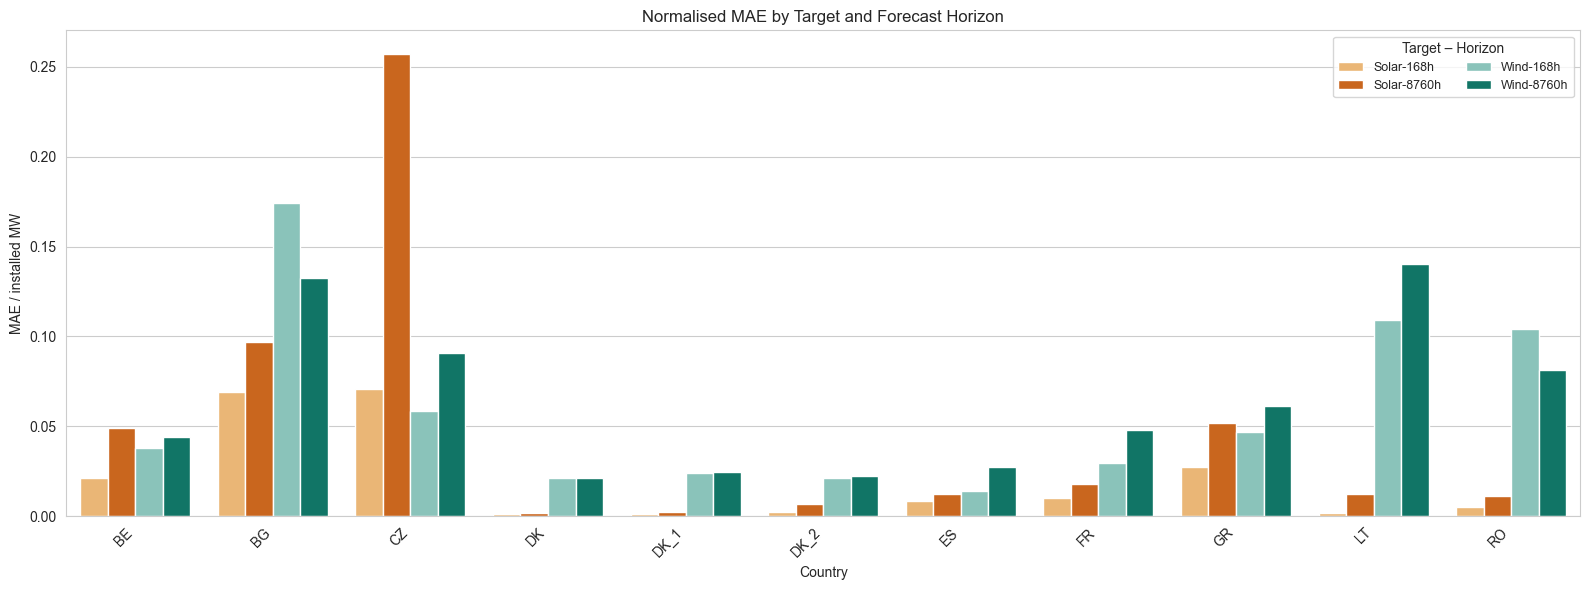

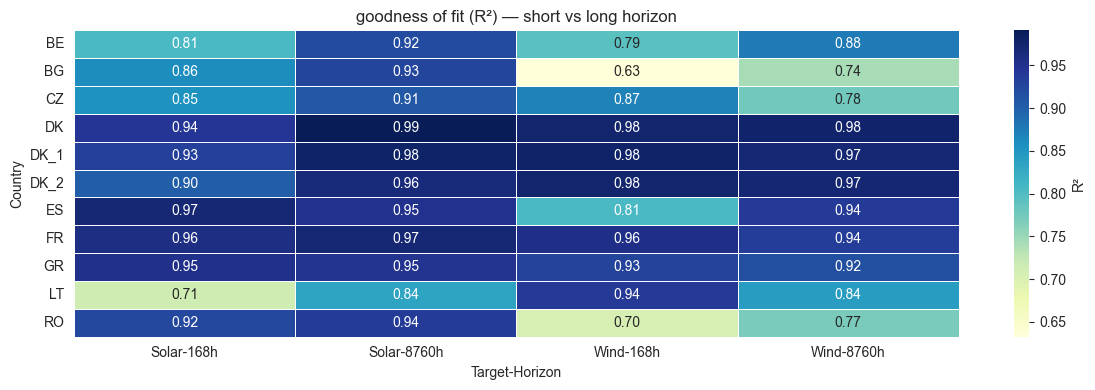

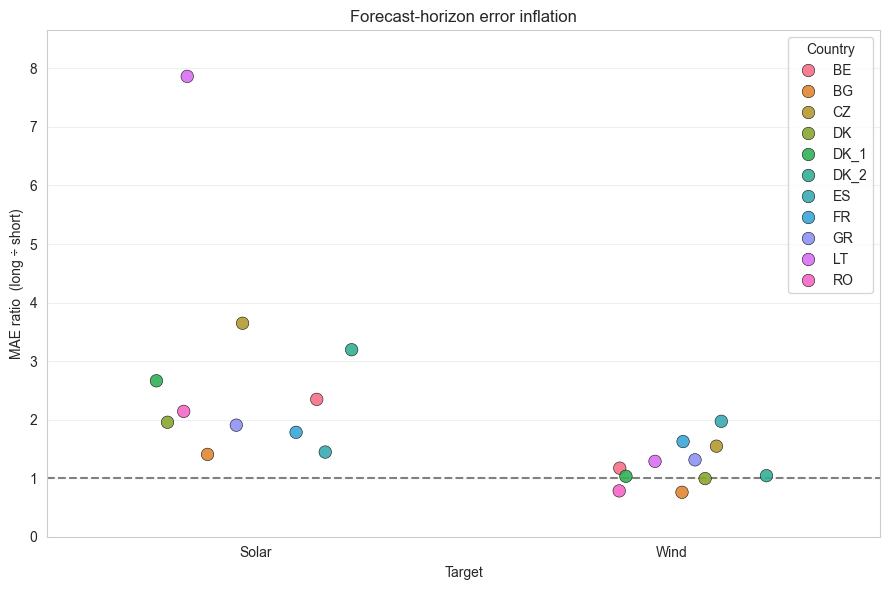

QUICK FACTS!!

SOLAR — 168 h forecast
  ▶️  Best 3 (lowest MAE):
Country  MAE_norm     R2
   DK_1  0.000922 0.9323
     DK  0.001009 0.9445
     LT  0.001560 0.7137
  ▶️  Worst 3 (highest MAE):
Country  MAE_norm     R2
     CZ  0.070593 0.8541
     BG  0.068966 0.8604
     GR  0.027185 0.9529

WIND — 168 h forecast
  ▶️  Best 3 (lowest MAE):
Country  MAE_norm     R2
     ES  0.013881 0.8055
   DK_2  0.021313 0.9755
     DK  0.021494 0.9754
  ▶️  Worst 3 (highest MAE):
Country  MAE_norm     R2
     BG  0.174441 0.6326
     LT  0.109113 0.9396
     RO  0.104026 0.7034
Horizon         168h  8760h
Region Target              
East   Solar   0.071  0.257
       Wind    0.059  0.091
North  Solar   0.001  0.006
       Wind    0.044  0.052
South  Solar   0.027  0.043
       Wind    0.085  0.076
West   Solar   0.015  0.033
       Wind    0.034  0.046

⚠️  Potential anomalies (long-horizon error > 2× short-horizon):
Country Target  MAE_ratio
     BE  Solar   2.346369
     CZ  Solar   3.646380
   

In [37]:
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import io



root      = pathlib.Path.cwd()
csv_path  = root / "gru_horizon_metrics.csv"
if not csv_path.exists():
    csv_path = root.parent / "gru_horizon_metrics.csv"

print("loading:", csv_path)
metrics = pd.read_csv(csv_path,
                      dtype={"Country":str, "Target":str, "Horizon":str},
                      na_values=["", "nan", "NaN", "inf", "-inf"])

metrics = metrics[~metrics["Country"].isin(["EE", "SI"])].reset_index(drop=True)






#removing strange values
mask_bad_r2  = metrics["R2"].abs() > 1.2
mask_bad_mae = metrics["MAE"] > metrics["MAE"].quantile(0.99) * 3
if mask_bad_r2.any() or mask_bad_mae.any():
    bad_rows = metrics[mask_bad_r2 | mask_bad_mae]
    print("removing suspicious rows:")
    display(bad_rows)
    metrics = metrics[~(mask_bad_r2 | mask_bad_mae)].reset_index(drop=True)




#normalising based on capacity 
cap_raw = """
Country,Solar_MW,Wind_on_MW,Wind_off_MW,Total_MW
BE,2818,1249,712,20105
BG,275,358,0,11285
CZ,2050,270,0,20725
DK,601,3574,1271,14942          # (DK_1+DK_2)
DK_1,421,2966,843,9407
DK_2,180,608,428,5535
ES,6535,22740,0,103806
FR,6191,10322,0,121039
GR,2429,1613,0,17625
LT,68,282,0,4466
RO,1101,2896,0,22590
"""

capacity = (pd.read_csv(io.StringIO(cap_raw), comment="#") 
            .fillna(0)
            .set_index("Country"))
capacity["Wind_MW"] = capacity["Wind_on_MW"] + capacity["Wind_off_MW"]

def match_cap(row):
    try:
        return (capacity.loc[row["Country"], "Solar_MW"]
                if row["Target"] == "Solar"
                else capacity.loc[row["Country"], "Wind_MW"])
    except KeyError:       
        return np.nan

metrics["Installed_MW"] = metrics.apply(match_cap, axis=1)
metrics = metrics.dropna(subset=["Installed_MW"])     

metrics["MAE_norm"]  = metrics["MAE"]  / metrics["Installed_MW"]
metrics["RMSE_norm"] = metrics["RMSE"] / metrics["Installed_MW"]









#3region tag seprataion 
REGIONS = {
    "North": {"DK", "DK_1", "DK_2",          "LT", "NO", "SE", "FI"},  
    "South": {"ES", "IT", "GR", "PT",        "RO", "BG"},             
    "West" : {"BE", "FR", "CH", "NL", "DE", "AT", "UK"},
    "East" : {"CZ", "PL", "HU", "RS", "SK"},
}

def to_region(code):
    code = code.split("_")[0]
    for r, cset in REGIONS.items():
        if code in cset:
            return r
    return "other"


metrics["Region"]  = metrics["Country"].apply(to_region)
metrics["Horizon"] = pd.Categorical(metrics["Horizon"],
                                    ["168h", "8760h"], ordered=True)
metrics["Target"]  = metrics["Target"].str.capitalize()






#4a. MAE barplot
plot_df = metrics.copy()

plot_df["Cat"] = (
        plot_df["Target"].astype(str).str.capitalize()
        + "-" +
        plot_df["Horizon"].astype(str)
)

cat_order   = ["Solar-168h", "Solar-8760h", "Wind-168h", "Wind-8760h"]
cat_palette = {
    "Solar-168h":  "#FDB863",
    "Solar-8760h": "#E66101",
    "Wind-168h":   "#80CDC1",
    "Wind-8760h":  "#018571",
}

plt.figure(figsize=(16, 6))
sns.barplot(
    data=plot_df,
    x="Country",
    y="MAE_norm",
    hue="Cat",
    hue_order=cat_order,
    palette=cat_palette,
    errorbar=None
)

plt.title("Normalised MAE by target and forecast horizon")
plt.ylabel("MAE / installed MW")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Target – Horizon", ncol=2, fontsize=9, title_fontsize=10)
plt.tight_layout()
plt.show()







#4b. R² heat-map
pivot_r2 = (
    metrics
    .pivot_table(index="Country",
                 columns=["Target", "Horizon"],
                 values="R2",
                 observed=False)        
    .sort_index()
)
plt.figure(figsize=(12, max(4, 0.35*len(pivot_r2))))
if sns:
    sns.heatmap(pivot_r2, annot=True, fmt=".2f",
                cmap="YlGnBu", linewidths=.5,
                cbar_kws={"label": "R²"})
else:
    plt.imshow(pivot_r2, aspect="auto", cmap="YlGnBu")
    plt.colorbar(label="R²")
    plt.xticks(range(pivot_r2.shape[1]), pivot_r2.columns, rotation=45, ha="left")
    plt.yticks(range(pivot_r2.shape[0]), pivot_r2.index)
plt.title("goodness of fit (R²) — short vs long horizon")
plt.tight_layout()
plt.show()










#4c. Long ÷ short MAE ratio scatter
short_mae = (metrics[metrics["Horizon"]=="168h"]
.set_index(["Country","Target"])["MAE_norm"])
long_mae  = (metrics[metrics["Horizon"]=="8760h"]
.set_index(["Country","Target"])["MAE_norm"])
ratio_df  = (long_mae / short_mae).rename("MAE_ratio").reset_index()

plt.figure(figsize=(9, 6))
if sns:
    sns.stripplot(
        data=ratio_df, x="Target", y="MAE_ratio",
        hue="Country", size=9, jitter=0.25, palette="husl",
        alpha=0.9, linewidth=0.4, edgecolor="black"
    )
else:
    #this if without seaborn
    for (x_val, tgt), col in zip([(0, "Solar"), (1, "Wind")],
                                 ("tab:blue", "tab:orange")):
        sub = ratio_df[ratio_df["Target"] == tgt]
        x = np.random.normal(x_val, 0.08, size=len(sub))
        plt.scatter(x, sub["MAE_ratio"], color=col, s=100, edgecolor="k", label=tgt)

plt.axhline(1, ls="--", c="grey")
plt.ylabel("MAE ratio  (long ÷ short)")
plt.title("Forecast-horizon error inflation")
plt.grid(axis="y", alpha=0.3)
plt.ylim(0, ratio_df["MAE_ratio"].max()*1.1)

#extreme points
# for _, row in ratio_df[ratio_df["MAE_ratio"] > 2.0].iterrows():
#     plt.text(row["Target"], row["MAE_ratio"]+0.05,
#              row["Country"], ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()







#5.summary
def best_worst(df, tgt):
    sub = df[(df.Target==tgt) & (df.Horizon=="168h")]
    return (sub.nsmallest(3,"MAE_norm")[["Country","MAE_norm","R2"]],
            sub.nlargest(3,"MAE_norm")[["Country","MAE_norm","R2"]])

print("QUICK FACTS!!")
for t in ("Solar","Wind"):
    best, worst = best_worst(metrics, t)
    print(f"\n{t.upper()} — 168 h forecast")
    print("  ▶️  Best 3 (lowest MAE):")
    print(best.to_string(index=False))
    print("  ▶️  Worst 3 (highest MAE):")
    print(worst.to_string(index=False))

region_avg = (metrics
              .groupby(["Region","Target","Horizon"], observed=False)
              .agg(MAE_mean=("MAE_norm","mean"))
              .round(3)
              .reset_index())


print(region_avg.pivot_table(index=["Region","Target"],
                             columns="Horizon",
                             values="MAE_mean",
                             observed=False))





#flagging extreme long/short inflation (>2×)
inflated = ratio_df[ratio_df["MAE_ratio"] > 2.0]
if not inflated.empty:
    print("\n⚠️  Potential anomalies (long-horizon error > 2× short-horizon):")
    print(inflated.to_string(index=False))
else:
    print("\nNo extreme long-horizon inflation detected (ratio ≤ 2).")


1. graph - how accurate is the prediction for a countries wind or solar short and long term
normalised based on how much the country produces 
higher worse 

2. graph - how well does the model predict/fit it overall for that category 
higher better

3. graph - how much is the long term prediction worse than the short term 
higher means worse 

- some potential analysis notes about outliers for the first graph 
- 
- **CZ – Solar-8760 h:** data-plus-climate effect. Only ~2 GW of PV, but deep winter irradiance swings (clear frost ↔ fog/snow). Year-ahead model can’t anticipate regime shifts, so error / MW skyrockets.

- **BG – Wind-168 h & Wind-8760 h:** complex orography (Balkan ridges, Black-Sea coast) yields sharp wind-field changes; both short- and long-range models struggle. Installed wind is just ~360 MW, so every absolute-error MW looms large after normalisation.

- **LT – Wind-8760 h:** Baltic winter storms: timing errors one year out inflate MAE. With only ~280 MW installed, the denominator is tiny, so MAE / MW soars.

- **BE – Solar-8760 h:** highly fragmented rooftop PV (~2.8 GW) often suffers snow cover & cloud micro-climatology that reanalysis misses on annual scales → elevated year-ahead MAE_norm.

- **DK-1 & DK-2 – all bars (low):** flat terrain, dense observations, and plenty of homogeneous data let the GRU nail forecasts; large installed bases ( >3 GW wind each) keep MAE_norm small.

- **DK (aggregated) – Solar bars (very low):** combined DK_1+DK_2 solar capacity (~600 MW) is large enough relative to the already small absolute errors, pushing MAE / MW toward zero.

- **GR – Solar-8760 h vs Wind:** steadier Mediterranean summer sun means solar year-ahead errors remain moderate, whereas complex Aegean jets make wind trickier.

- **ES – all bars (mid-pack):** absolute MAE is big, but Spain’s huge denominators (6.5 GW PV, 22 GW wind) dampen MAE_norm. Year-ahead solar still rises, but not outrageously.

- **RO – Wind bars (high):** Dobrogea corridor turbines face Black-Sea mesoscale jets that reanalysis misses, especially at annual lead times, hence wind MAE_norm beats solar.


second graph outliers

- **BG – Wind-168 h  (R² ≈ 0.63)**  
  Balkan mountains + Black-Sea breeze create sharp wind-field gradients that the coarse re-analysis misses; tiny installed fleet (~360 MW) means each mis-forecast MW weighs heavily.

- **LT – Solar-168 h  (R² ≈ 0.71)**  
  High-latitude winter irradiation is extremely low and sensitive to snow cover. Satellite/re-analysis bias + only 68 MW of PV → low signal-to-noise for the model.

- **RO – Wind-168 h  (R² ≈ 0.70)**  
  Dobrogea corridor jets switch abruptly with synoptic fronts; one-week GRU can’t capture timing, degrading the fit despite a 2.9 GW denominator.

---



third scatter outliers
- **LT – Solar  (ratio ≈ 8)**  
  Same snow/latitude issue plus minuscule PV fleet: any absolute error in a snowy week is amplified eight-fold once divided by installed MW.

- **CZ – Solar  (≈ 3.6)**  
  Czech PV is almost entirely summer-peaking rooftop. Year-ahead model doesn’t “know” next summer’s cloud statistics, so long-range MAE balloons.

- **DK_1 & DK_2 – Solar  (≈ 3.2 / 2.7)**  
  Denmark’s solar baseline is just ~600 MW versus >4 GW of wind. Absolute errors stay small, but the small divisor makes long-horizon MAE_norm look 3× worse.

- **BE – Solar  (≈ 2.3)**  
  Thick, variable North-Sea cloud decks + rooftop PV heterogeneity: model’s year-ahead irradiance guess frequently off by whole days.

- **RO – Solar  (≈ 2.1)**  
  Patchy PV in the Carpathian foothills; local fog events poorly resolved at 1-year lead times.

- **DK_2 – Wind  (ratio ≈ 1.9)** and **FR – Wind  (≈ 2.0)**  
  Offshore-dominant DK_2 suffers when the annual North-Sea storm track is mis-timed; France’s mistral/Atlantic regimes flip unpredictably year-to-year.